

# Jazz Extract EDA
Explore the extracted jazz DB and prototype new fields against the raw dump.

In [ ]:
from __future__ import annotations

import struct
import sys
from pathlib import Path

import dask.dataframe as dd
import mwparserfromhell
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt
from sqlalchemy import create_engine

# Make the src package importable from notebooks/
REPO = Path("../").resolve()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from wiki_dumps.parse.stream import iter_pages_from_xml_bytes

DB_PATH  = REPO / "data/databases/jazz.db"
DUMP_DIR = REPO / "data/dumps"

engine = create_engine(f"sqlite:///{DB_PATH}")
print("DB:", DB_PATH)
print("Dump dir:", DUMP_DIR)

DB: /home/benwright/Documents/GitHub/wiki/data/databases/jazz.db
Dump dir: /home/benwright/Documents/GitHub/wiki/data/dumps


## 1  Load tables

In [ ]:
artists = pd.read_sql_table("jazz_artists", engine)
albums  = pd.read_sql_table("jazz_albums",  engine)
genres  = pd.read_sql_table("jazz_genres",  engine)
runs    = pd.read_sql_table("extraction_runs", engine)

engine.dispose()

print(f"artists={len(artists):,}  albums={len(albums):,}  genres={len(genres):,}")
runs[["schema_name","pages_processed","pages_matched","started_at","completed_at","status"]]

artists=10,881  albums=1,386  genres=62


,schema_name,pages_processed,pages_matched,started_at,completed_at,status


## 2  Artists EDA

In [ ]:
artists.info()
display(artists.head(3))

<class 'pandas.DataFrame'>
RangeIndex: 10881 entries, 0 to 10880
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  10881 non-null  int64  
 1   page_id             10881 non-null  int64  
 2   title               10881 non-null  str    
 3   full_name           7938 non-null   str    
 4   birth_year          7118 non-null   float64
 5   death_year          3383 non-null   float64
 6   nationality         1279 non-null   str    
 7   instruments         5762 non-null   str    
 8   genres              7251 non-null   str    
 9   active_years_start  3678 non-null   float64
 10  active_years_end    0 non-null      object 
 11  labels              3867 non-null   str    
dtypes: float64(3), int64(2), object(1), str(6)
memory usage: 1.6+ MB


,id,page_id,title,full_name,birth_year,death_year,nationality,instruments,genres,active_years_start,active_years_end,labels
0,1,8176,Dave Brubeck,NaN,1920.0,2012.0,NaN,Piano,Jazz\n Cool jazz\n West Coast jazz\n Third stream,2012.0,None,Fantasy\n Columbia\n Legacy\n Sony\n Decca\n A...
1,2,7668,Charles Mingus,Charles Mingus,1922.0,1979.0,"[[Los Angeles]], California, U.S.",Double bass|piano|vocals,Jazz|hard bop|bebop|avant-garde jazz|post-bop|...,1943.0,None,Atlantic|Candid|Columbia|Debut|Impulse!|Mercur...
2,3,10672,Frank Zappa,Frank Zappa,1940.0,1993.0,"Los Angeles, California, U.S.",NaN,Rock|progressive rock|blues|experimental|jazz|...,1955.0,None,Verve|Bizarre|Straight|DiscReet|Zappa|Barking ...


In [ ]:
# Null rates
(artists.isna().mean() * 100).sort_values(ascending=False).rename("null %").to_frame()

,null %
active_years_end,100.000000
nationality,88.245566
death_year,68.909108
active_years_start,66.197960
labels,64.460987
instruments,47.045308
birth_year,34.583218
genres,33.360904
full_name,27.047146
title,0.000000


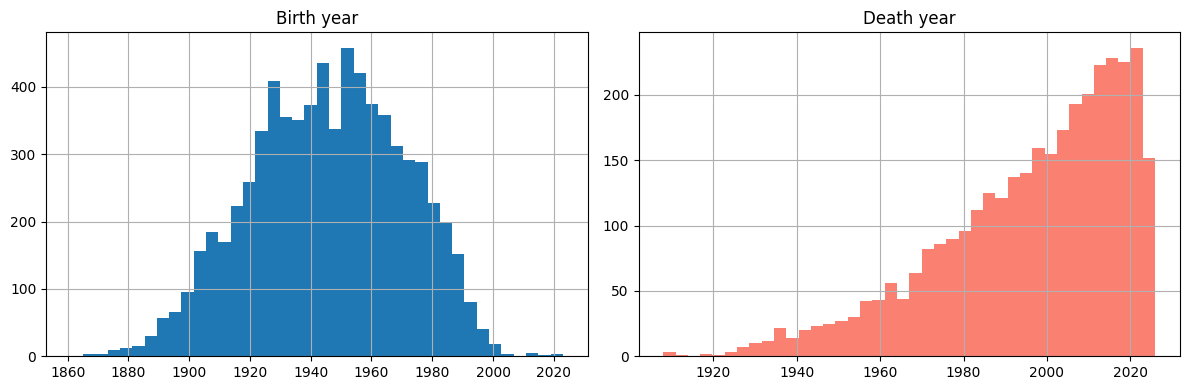

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
artists["birth_year"].dropna().astype(int).hist(bins=40, ax=axes[0])
axes[0].set_title("Birth year")
artists["death_year"].dropna().astype(int).hist(bins=40, ax=axes[1], color="salmon")
axes[1].set_title("Death year")
plt.tight_layout()

<Axes: title={'center': 'Top instruments'}, ylabel='instruments'>

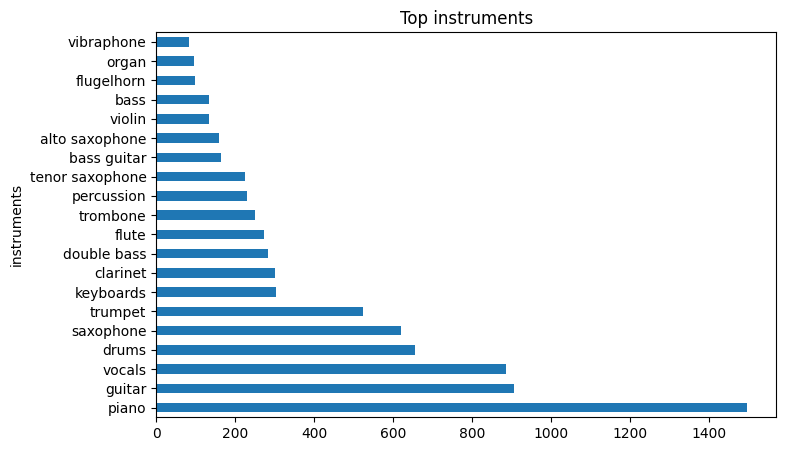

In [ ]:
import re as _re

import mwparserfromhell as _mwp

_LIST_TMPLS = frozenset({"hlist", "flatlist", "plainlist", "unbulleted list", "ubl"})


def _clean_wiki_list(raw: str) -> list[str]:
    """Return plain-text items from a raw wikitext list value."""
    wc = _mwp.parse(raw)
    items: list[str] = []
    for tmpl in wc.filter_templates():
        if str(tmpl.name).strip().lower() in _LIST_TMPLS:
            for param in tmpl.params:
                if not param.showkey:
                    item = _mwp.parse(str(param.value)).strip_code().strip()
                    if item:
                        items.append(item)
    if not items:
        plain = wc.strip_code().strip()
        items = [i.strip() for i in _re.split(r"[,|\n]+", plain) if i.strip()]
    return items


# Top instruments (pipe-separated, clean wikitext markup)
(
    artists["instruments"]
    .dropna()
    .apply(_clean_wiki_list)
    .explode()
    .str.strip()
    .str.lower()
    .value_counts()
    .head(20)
    .plot.barh(figsize=(8, 5), title="Top instruments")
)


<Axes: title={'center': 'Top nationalities'}, ylabel='nationality'>

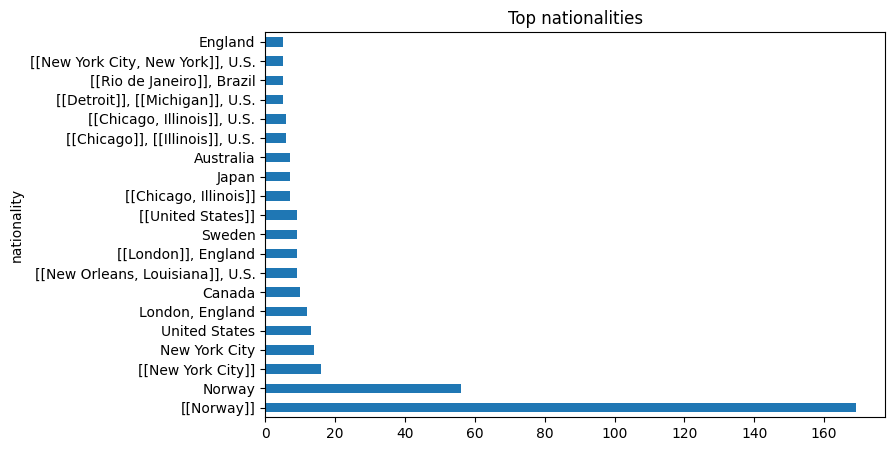

In [ ]:
# Top nationalities
artists["nationality"].dropna().apply(_clean_wiki_list).explode().str.strip().str.lower().value_counts().head(20).plot.barh(figsize=(8, 5), title="Top nationalities")

<Axes: title={'center': 'Active start decade'}, xlabel='active_years_start'>

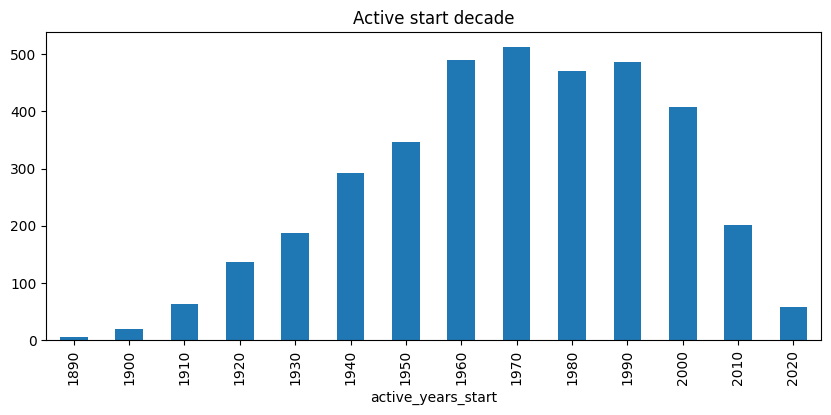

In [ ]:
# Decades active
decade = (artists["active_years_start"].dropna().astype(int) // 10 * 10)
decade.value_counts().sort_index().plot.bar(figsize=(10, 4), title="Active start decade")

## 3  Albums & Genres EDA

,id,page_id,title,artist,release_year,label,genres,personnel
0,1,16422,Joni Mitchell,NaN,NaN,{{flatlist|\n* [[Reprise Records|Reprise]]\n* ...,Folk\n pop\n jazz\n rock,NaN
1,2,148057,Family Man (Black Flag album),[[Black Flag (band)|Black Flag]],1984.0,[[SST Records|SST]] (026),Spoken word|punk rock|free jazz|avant-garde jazz,NaN
2,3,196161,Kind of Blue,[[Miles Davis]],1959.0,[[Columbia Records|Columbia]],Modal jazz,NaN
3,4,306726,Bitches Brew,[[Miles Davis]],1970.0,[[Columbia Records|Columbia]],Jazz fusion|avant-garde jazz|jazz rock|avant-f...,NaN
4,5,586374,Miles Ahead (album),[[Miles Davis]],1957.0,[[Columbia Records|Columbia]],Cool jazz|third stream,NaN
5,6,594377,Gling-Gló,[[Björk Guðmundsdóttir & tríó Guðmundar Ingólf...,1990.0,{{hlist|[[Smekkleysa]]|[[One Little Independen...,Vocal jazz,NaN
6,7,617508,The Girl in the Other Room,[[Diana Krall]],2004.0,[[Verve Records|Verve]],Jazz,NaN
7,8,889658,Tidal (album),[[Fiona Apple]],1996.0,* [[Work Group|Work]]\n* [[Columbia Records|Co...,Chamber pop|jazz pop|alternative pop,NaN
8,9,902560,"Grammy Award for Best Jazz Vocal Performance, ...",NaN,NaN,NaN,NaN,NaN
9,10,902563,"Grammy Award for Best Jazz Vocal Performance, ...",NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Album release years')

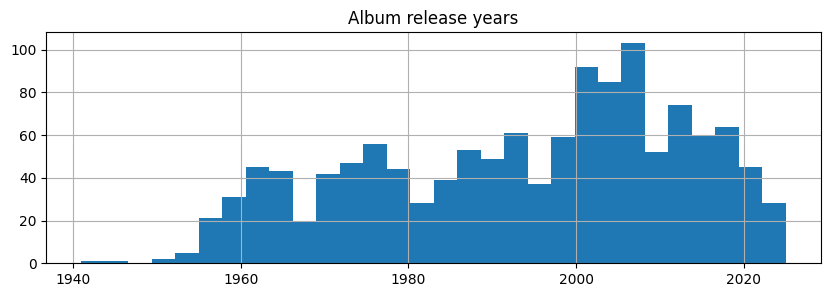

In [ ]:
display(albums.head(20))
albums["release_year"].dropna().astype(int).hist(bins=30, figsize=(10, 3))
plt.title("Album release years")

In [ ]:
display(genres[["title","parent_genre","description"]].sort_values("title"))

,title,parent_genre,description
16,Acid jazz,{{hlist|[[Jazz fusion]]|[[soul music|soul]]|[[...,"Acid jazz (also known as club jazz, psychedeli..."
25,Afro-Cuban jazz,{{hlist|[[Son cubano]]|[[son montuno]]|[[jazz]]}},Afro-Cuban jazz is the earliest form of Latin ...
14,Avant-garde jazz,* [[Jazz]]\n* [[bebop]]\n* [[Modernism (music)...,"Avant-garde jazz (also known as avant-jazz, ex..."
51,Balkan jazz,NaN,Balkan jazz is an umbrella term for jazz from ...
2,Bebop,* [[Swing music|Swing]]\n* [[Kansas City jazz]],Bebop or bop is a style of jazz developed in t...
...,...,...,...
26,Trad jazz,NaN,"thumb|London's Tranquil Valley Stompers, 1961"
1,Twelve-bar blues,NaN,The twelve-bar blues (or blues changes) is one...
23,Western swing,{{hlist|[[Swing music|Swing]]|[[Dixieland]]|[[...,"Western swing, also known as country jazz, is ..."
41,Yass (music),NaN,Yass (jass) is a Polish music style of avant-g...


## 4  Wikitext lookup from preprocessed dump

Given a `page_id`, find its block in the raw dump and return the parsed `WikiPage`.

In [ ]:
from wiki_dumps.dumps.index import parse_index
from wiki_dumps.dumps.preprocess import load_raw_index, raw_paths

# Locate dump files
_dump_files = sorted(DUMP_DIR.glob("*-pages-articles-multistream.xml.bz2"))
assert _dump_files, f"No dump found in {DUMP_DIR}"
DUMP_PATH  = _dump_files[-1]
INDEX_PATH = Path(str(DUMP_PATH).replace(
    "-pages-articles-multistream.xml.bz2",
    "-pages-articles-multistream-index.txt.bz2",
))
RAW_PATH, IDX_PATH = raw_paths(DUMP_PATH)

print("Dump: ", DUMP_PATH.name)
print("Raw:  ", RAW_PATH.name, "exists:", RAW_PATH.exists())
print("Index:", IDX_PATH.name, "exists:", IDX_PATH.exists())

Dump:  enwiki-20260301-pages-articles-multistream.xml.bz2
Raw:   enwiki-20260301-pages-articles-multistream.xml.raw exists: True
Index: enwiki-20260301-pages-articles-multistream.xml.raw.idx exists: True


In [ ]:
import bz2

import numpy as np

from wiki_dumps.dumps.preprocess import load_raw_index, raw_paths

RAW_PATH, IDX_PATH = raw_paths(DUMP_PATH)
_raw_index = load_raw_index(IDX_PATH)   # list[(offset, length)] — small binary file

# Stream the bz2 index line-by-line into two numpy arrays.
# Avoids creating millions of Python IndexEntry objects (~1 GB saved vs parse_index).
_pids: list[int] = []
_blks: list[int] = []
block_idx = -1
prev_offset = -1

with bz2.open(INDEX_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        line = line.rstrip("\n")
        fc = line.index(":")
        sc = line.index(":", fc + 1)
        offset  = int(line[:fc])
        page_id = int(line[fc + 1 : sc])
        if offset != prev_offset:
            block_idx += 1
            prev_offset = offset
        _pids.append(page_id)
        _blks.append(block_idx)

_pid_arr = np.array(_pids, dtype=np.int64)
_blk_arr = np.array(_blks, dtype=np.int32)
# Sort by page_id for O(log n) searchsorted lookups
_sort_order = np.argsort(_pid_arr, kind="stable")
_pid_arr = _pid_arr[_sort_order]
_blk_arr = _blk_arr[_sort_order]
del _pids, _blks, _sort_order

print(f"Index: {len(_pid_arr):,} pages, {_blk_arr.max()+1:,} blocks")
print(f"Memory: {(_pid_arr.nbytes + _blk_arr.nbytes) / 1e6:.1f} MB")


Index: 25,432,678 pages, 254,363 blocks
Memory: 305.2 MB


In [ ]:
from wiki_dumps.parse.types import WikiPage


def fetch_page(page_id: int) -> WikiPage | None:
    """Return the WikiPage for *page_id* by seeking into the raw dump."""
    pos = int(np.searchsorted(_pid_arr, page_id))
    if pos >= len(_pid_arr) or _pid_arr[pos] != page_id:
        return None
    block_idx = int(_blk_arr[pos])
    offset, length = _raw_index[block_idx]
    with RAW_PATH.open("rb") as fh:
        fh.seek(offset)
        xml_bytes = fh.read(length)
    for page in iter_pages_from_xml_bytes(xml_bytes):
        if page.page_id == page_id:
            return page
    return None


def fetch_wikitext(page_id: int) -> str:
    page = fetch_page(page_id)
    return page.wikitext if page else ""


# Quick smoke test
sample_pid = int(artists["page_id"].iloc[0])
page = fetch_page(sample_pid)
if page:
    print(f"{page.title!r}  ({len(page.wikitext):,} chars)")
    print(page.wikitext[:500])


'Dave Brubeck'  (54,145 chars)
{{short description|American jazz pianist and composer (1920–2012)}}
{{Use American English|date = November 2019}}
{{Use mdy dates|date=December 2013}}
{{Infobox musical artist
| image            = Dave Brubeck (1964).jpg
| caption          = Brubeck in 1964
| birth_name       = David Warren Brubeck
| birth_date       = {{Birth date|1920|12|06}}
| birth_place      = [[Concord, California]], U.S.
| instrument       = Piano
| death_date       = {{Death date and age|2012|12|05|1920|12|06}}
| death_


## 5  Prototype new extract fields

Grab a sample of artists, fetch their wikitext, and try parsing a new field — e.g. **awards** from the infobox.
Once happy with the regex / template logic, copy it into `jazz.py`.

In [ ]:
def _infobox_value(wikicode, key: str) -> str | None:
    for tmpl in wikicode.filter_templates():
        if tmpl.has(key):
            return str(tmpl.get(key).value).strip() or None
    return None


# ── prototype a new field here ────────────────────────────────────────────
def extract_new_fields(page_id: int) -> dict:
    wikitext = fetch_wikitext(page_id)
    if not wikitext:
        return {"awards": None, "associated_acts": None}
    wikicode = mwparserfromhell.parse(wikitext)
    return {
        "awards":          _infobox_value(wikicode, "awards"),
        "associated_acts": _infobox_value(wikicode, "associated_acts"),
        # add more keys here to prototype additional fields
    }


# Run on a small sample (slow — one disk seek per page)
SAMPLE_N = 20
sample = artists.head(SAMPLE_N).copy()
new_fields = pd.DataFrame(
    [extract_new_fields(int(pid)) for pid in sample["page_id"]],
    index=sample.index,
)
display(pd.concat([sample[["title", "birth_year", "instruments"]], new_fields], axis=1))

,title,birth_year,instruments,awards,associated_acts
0,Dave Brubeck,1920.0,Piano,NaN,NaN
1,Charles Mingus,1922.0,Double bass|piano|vocals,NaN,NaN
2,Frank Zappa,1940.0,NaN,NaN,NaN
3,Bing Crosby,1903.0,NaN,NaN,NaN
4,Django Reinhardt,1910.0,Guitar|violin|banjo,NaN,NaN
5,George Benson,1943.0,Vocals|guitar,NaN,NaN
6,Louis Armstrong,1901.0,Vocals|trumpet,NaN,NaN
7,George Gershwin,1898.0,NaN,NaN,NaN
8,Harry Connick Jr.,1967.0,NaN,NaN,NaN
9,Frank Sinatra,1915.0,Vocals,[[List of awards and nominations received by F...,NaN


## 6  Lazy Dask DataFrame with computed wikitext column

A Dask DataFrame backed by the artists table. The `wikitext` column is a
delayed lookup — nothing is read from disk until `.compute()` is called
(or you trigger an action on a subset).

In [ ]:
import dask

# Wrap artists as a Dask dataframe
ddf = dd.from_pandas(artists, npartitions=8)

# Add a lazy wikitext column (one disk seek per row on compute)
ddf = ddf.assign(wikitext=ddf["page_id"].map(fetch_wikitext, meta=("wikitext", "str")))

print(ddf)   # nothing fetched yet
ddf.dtypes

Dask DataFrame Structure:
                  id page_id   title full_name birth_year death_year nationality instruments  genres active_years_start active_years_end  labels wikitext
npartitions=8                                                                                                                                            
0              int64   int64  string    string    float64    float64      string      string  string            float64           string  string      str
1361             ...     ...     ...       ...        ...        ...         ...         ...     ...                ...              ...     ...      ...
...              ...     ...     ...       ...        ...        ...         ...         ...     ...                ...              ...     ...      ...
9521             ...     ...     ...       ...        ...        ...         ...         ...     ...                ...              ...     ...      ...
10880            ...     ...     ...       ...    

id                      int64
page_id                 int64
title                  string
full_name              string
birth_year            float64
death_year            float64
nationality            string
instruments            string
genres                 string
active_years_start    float64
active_years_end       string
labels                 string
wikitext                  str
dtype: object

In [ ]:
# Materialize a small slice — fetches wikitext for those rows
sample_lazy = ddf.head(5)   # triggers compute on first partition
sample_lazy[["title", "wikitext"]].assign(
    wikitext_len=sample_lazy["wikitext"].str.len()
)[["title", "wikitext_len"]]

,title,wikitext_len
0,Dave Brubeck,54145
1,Charles Mingus,53947
2,Frank Zappa,219905
3,Bing Crosby,138971
4,Django Reinhardt,71396


In [ ]:
# Example: compute average wikitext length across all artists
# (reads every page from disk — takes a while for the full table)
# Uncomment when you want the full run:
# avg_len = ddf["wikitext"].str.len().mean().compute()
# print(f"Mean wikitext length: {avg_len:,.0f} chars")

## 7  Inspect a single page interactively

In [ ]:
# Change TITLE to any artist/album title in the DB
TITLE = artists["title"].iloc[0]

row  = artists[artists["title"] == TITLE].iloc[0]
page = fetch_page(int(row["page_id"]))

if page:
    wikicode = mwparserfromhell.parse(page.wikitext)
    print(f"== {page.title} ==")
    print(f"categories: {page.categories}")
    print()
    # Show all infobox keys found
    for tmpl in wikicode.filter_templates():
        if "infobox" in str(tmpl.name).lower():
            print(f"Infobox: {tmpl.name.strip()}")
            for param in tmpl.params:
                val = str(param.value).strip()
                if val:
                    print(f"  {param.name.strip()!s:30s} = {val[:80]}")
            break

== Dave Brubeck ==
categories: ('1920 births', '2012 deaths', 'A&M Records artists', 'American jazz composers', 'American male jazz composers', 'American jazz pianists', 'American male jazz pianists', 'American jazz songwriters', 'American male songwriters', 'United States Army personnel of World War II', 'Atlantic Records artists', 'Bebop ensembles', 'Catholics from California', 'Catholics from Connecticut', 'Columbia Records artists', 'Concord Records artists', 'Converts to Roman Catholicism', 'Cool jazz pianists', 'Dave Brubeck Quartet members', 'Decca Records artists', 'DownBeat Jazz Hall of Fame members', 'Fantasy Records artists', 'Fellows of the American Academy of Arts and Sciences', 'Grammy Lifetime Achievement Award winners', 'Jazz musicians from California', 'Kennedy Center honorees', 'Laetare Medal recipients', 'Members of Phi Kappa Phi', 'Musicians from Norwalk, Connecticut', 'Musicians from the San Francisco Bay Area', 'Naxos Records artists', 'People from Amador County, 